# PyTorch Neural Network Development

This notebook develops the networks that we will use in PyTorch.


In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


##  Create a neural network with a configurable number of inputs and hidden layers 

In [2]:
def get_dated_filename(filename):

    # datetime object containing current date and time
    now = datetime.now()
    dt_str = now.strftime("%Y-%m-%d_%H-%M-%S-%f")
    filename = filename + '_' + dt_str + '.pickle'
    return filename

class TanhNet(nn.Module):
    def __init__(self, n_inputs=2, n_hidden=3):
        super(TanhNet, self).__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.tanh(x)
        x = self.fc2(x)
        output = x
        return output

class ReluNet(nn.Module):
    def __init__(self, n_inputs=2, n_hidden=3):
        super(ReluNet, self).__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        output = x
        return output

class FFNN():
    """General FFNN Class"""

    def __init__(
            self, net_type='tanh',
            n_inputs=2, n_hidden=3,
            lr=0.001, momentum=0.9,
            rho=0.9, eps=1e-06,
            betas=(0.9, 0.999), weight_decay=0,
            ams_grad=False,
            use_gpu=True, optimizer_method='sgd'):
        """Initializes the FFNN wrapper class"""

        self.use_gpu = use_gpu
        self.optimizer_method = optimizer_method

        # Initialize the network
        if net_type == 'tanh':
            self.net = TanhNet(n_inputs=n_inputs, n_hidden=n_hidden)
        else:
            self.net = ReluNet(n_inputs=n_inputs, n_hidden=n_hidden)

        # If using GPU and GPU is available set device to GPU
        if use_gpu:
            self.device = torch.device(
                "cuda:0" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device("cpu")
        
        self.net.to(self.device)

        # Define a criterion and optimizer
        self.criterion = nn.MSELoss()

        if self.optimizer_method == 'adadelta':
            self.optimizer = optim.Adadelta(
                self.net.parameters(), lr=lr,
                rho=rho, eps=eps,
                weight_decay=weight_decay)
        elif self.optimizer_method == 'adadelta':
            self.optimizer = optim.Adam(
                self.net.parameters(), lr=lr,
                betas=betas, eps=eps,
                weight_decay=weight_decay,
                amsgrad=ams_grad)
        else:
            self.optimizer = optim.SGD(
                self.net.parameters(), lr=lr, momentum=momentum
            )

    def fit(self, x, y, n_epochs=2):
        """Fits the model - like scikit fit"""

        print('Fitting using device: {}'.format(self.device))

        batch_size = x.shape[0]

        # Prepare for torch
        x = torch.from_numpy(x).float()
        y = torch.from_numpy(y).float()

        # get the data to the device
        x_device, y_device = x.to(self.device), y.to(self.device)

        for epoch in range(n_epochs):

            running_loss = 0.0

            for idx in range(batch_size):

                # Get the current sample
                x_sample = x_device[idx, :]
                y_sample = y_device[idx]

                # Zero the parameter gradients;
                # equivalent to self.optimizer.zero_grad()
                # but faster.
                for param in self.net.parameters():
                    param.grad = None

                # Forward + backward + optimizer
                y_hat_sample = self.net(x_sample)
                loss = self.criterion(y_sample, y_hat_sample)
                loss.backward()
                self.optimizer.step()

                # Print statistics
                item_loss = loss.item()
                running_loss += item_loss

            print('[%d] running loss: %f' % (epoch + 1, running_loss))

        print('Finished Training.')

    def infer(self, x):

        # Prep the data for torch
        x = torch.from_numpy(x).float()

        # Move the data to the device
        if self.use_gpu:
            x_device = x.to(self.device)
        else:
            x_device = x

        y_device = self.net(x_device)

        if self.device == 'cpu':
            y_numpy = y_device.detach().numpy()
        else:
            y_numpy = y_device.cpu().detach().numpy()

        return y_numpy 

    def save(self, filename):
        filename = get_dated_filename(filename)
        with open(filename, 'wb') as fh:
            pickle.dump(self, fh)
        return filename

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            return pickle.load(f)

    def get_w1(self):
        if self.device == 'cpu':
            return ffnn.net.fc1.weight.detach().numpy()
        else:
            return ffnn.net.fc1.weight.cpu().detach().numpy()

    def get_b1(self):
        if self.device == 'cpu':
            return ffnn.net.fc1.bias.detach().numpy().reshape(-1,1)
        else:
            return ffnn.net.fc1.bias.cpu().detach().numpy().reshape(-1,1)

    def get_w2(self):
        if self.device == 'cpu':
            return ffnn.net.fc2.weight.detach().numpy()
        else:
            return ffnn.net.fc2.weight.cpu().detach().numpy()

    def get_b2(self):
        if self.device == 'cpu':
            return ffnn.net.fc2.bias.detach().numpy().reshape(-1,1)
        else:
            return ffnn.net.fc2.bias.cpu().detach().numpy().reshape(-1,1)


## Generate some interrogation signals

Here we generate some example data to train the networks on.


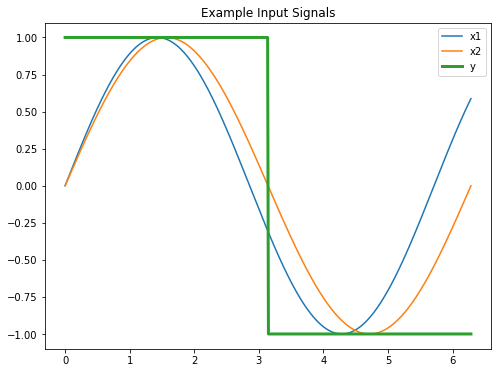

In [3]:
n_samples = 500
t = np.linspace(0, 2*np.pi, n_samples)
omega1 = 1.1
omega2 = 1

x1 = np.sin(omega1*t)
x2 = np.sin(omega2*t)

x = np.hstack(
    (x1.reshape(-1, 1), x2.reshape(-1, 1)))

y = -2*(np.heaviside(t - np.pi, 0.5) - 0.5)

fig, axs = plt.subplots(figsize=(8,6))
axs.plot(t, x)
axs.plot(t, y, linewidth=3)
axs.set_title('Example Input Signals')
axs.legend(('x1', 'x2', 'y'))

## Instantiate the Neural Net

In [4]:
ffnn = FFNN(
    net_type='relu',
    n_inputs=2, n_hidden=70,
    lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06,
    betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam')


## Fit the neural network

In [5]:
# Fit a function
ffnn.fit(x, y, n_epochs=100)


Fitting using device: cuda:0
[1] running loss: 14.909767
[2] running loss: 25.913312
[3] running loss: 26.139695
[4] running loss: 24.839282
[5] running loss: 22.365892
[6] running loss: 19.640537
[7] running loss: 17.521923
[8] running loss: 16.445291
[9] running loss: 16.324972
[10] running loss: 16.804903
[11] running loss: 17.493498
[12] running loss: 18.112391
[13] running loss: 18.467689
[14] running loss: 18.444180
[15] running loss: 18.022813
[16] running loss: 17.301134
[17] running loss: 16.442793
[18] running loss: 15.634490
[19] running loss: 14.961635
[20] running loss: 14.438149
[21] running loss: 14.017554
[22] running loss: 13.679556
[23] running loss: 13.287789
[24] running loss: 12.905922
[25] running loss: 12.501466
[26] running loss: 12.065651
[27] running loss: 11.632929
[28] running loss: 11.225477
[29] running loss: 10.841477
[30] running loss: 10.524469
[31] running loss: 10.253076
[32] running loss: 9.997903
[33] running loss: 9.811645
[34] running loss: 9.6203

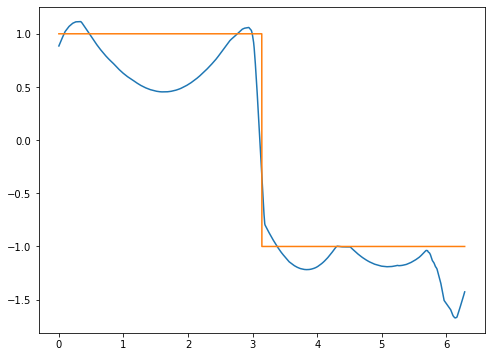

In [6]:
# Use the infer interface to rapidly get results for slightly different signals
n_samples = 800000
t = np.linspace(0, 2*np.pi, n_samples)
omega1 = 1.11
omega2 = 0.99

x1 = np.sin(omega1*t)
x2 = np.sin(omega2*t)

x = np.hstack(
    (x1.reshape(-1, 1), x2.reshape(-1, 1)))

y = -2*(np.heaviside(t - np.pi, 0.5) - 0.5)

y_net = ffnn.infer(x)

fig, axs = plt.subplots(figsize=(8, 6))
axs.plot(t, y_net)
axs.plot(t, y)


## Save the model

In [7]:
# Save the trained model
path = './models/ffnn'
filename = ffnn.save(path)


In [8]:
ffnn2 = FFNN.load(filename)


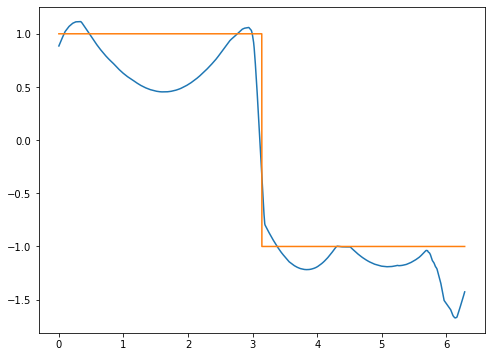

In [9]:
# Use the infer interface on the loaded network
y_net2 = ffnn2.infer(x)

fig, axs = plt.subplots(figsize=(8, 6))
axs.plot(t, y_net2)
axs.plot(t, y)

## Make a network in numpy and confirm it is the same

In [10]:
print('\n\nparameters:\n')

for name, param in ffnn.net.named_parameters():
    print(name)
    print(param)



parameters:

fc1.weight
Parameter containing:
tensor([[ 0.1219,  0.5098],
        [ 0.1547, -0.2807],
        [ 0.1831,  0.7124],
        [ 0.5702, -0.6003],
        [ 0.4999, -0.2894],
        [-0.6590,  0.5625],
        [ 0.2574,  0.1024],
        [ 0.7872,  0.4844],
        [ 0.1558, -0.5649],
        [ 0.5059,  0.3038],
        [ 0.4508,  0.6150],
        [-0.1305,  0.7002],
        [ 0.1591,  0.3973],
        [ 0.5462,  0.1841],
        [-0.2047, -0.3299],
        [ 0.1566,  0.0610],
        [-0.0693, -0.9609],
        [ 0.0746,  0.3149],
        [ 0.1841, -0.0432],
        [-0.5970,  0.1621],
        [-1.1176,  1.2274],
        [ 0.9948, -1.0146],
        [ 0.9125,  0.1600],
        [-0.2581, -0.4269],
        [ 0.2809,  0.4287],
        [-0.2416, -0.9333],
        [ 0.3926,  0.3410],
        [-0.4487,  0.6128],
        [ 0.2142,  1.0049],
        [-0.5132,  0.6111],
        [ 0.0930,  0.5961],
        [-0.6868, -1.3656],
        [ 0.1128,  0.3700],
        [-0.3857,  0.5831],


In [11]:
def relu(x):
    return np.maximum(x, 0)

y_relu_eq = ffnn.get_w2() @ relu(ffnn.get_w1() @ x.T + ffnn.get_b1()) + ffnn.get_b2()


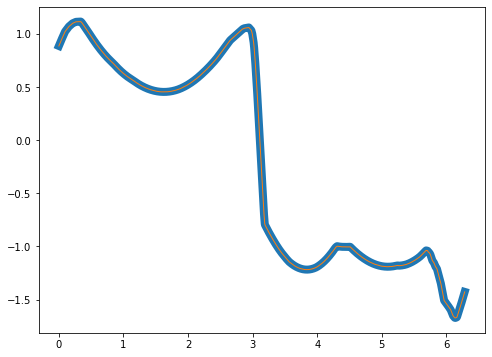

In [12]:
fig, axs = plt.subplots(figsize=(8, 6))
axs.plot(t, y_relu_eq.reshape(-1), linewidth=8)
axs.plot(t, y_net, linewidth=1)